# Evaluar un clasificador para detectar piezas que requieren inspección

Este notebook presenta un flujo independiente para medir el desempeño de un modelo binario. El ejemplo utiliza datos sintéticos de un proceso de manufactura: la clase positiva indica que una pieza debe pasar a inspección adicional.

El objetivo es practicar la lectura de métricas y errores, no construir un sistema de decisión para producción.

## Objetivo

Al finalizar podrás:

- calcular la proporción de predicciones correctas;
- interpretar una matriz de confusión;
- comparar un modelo contra una referencia sencilla;
- observar cómo un umbral distinto cambia los falsos positivos y negativos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 17

## 1. Preparar las herramientas

### ¿Qué se importa y por qué?

Este bloque reúne las herramientas que se utilizarán durante todo el análisis. `numpy` y `pandas` ayudan a manipular datos; `matplotlib` permite visualizar resultados; y `scikit-learn` aporta la generación de datos, los modelos, la separación de muestras y las métricas.

La constante `RANDOM_STATE` fija la semilla aleatoria. Así, otra persona puede ejecutar el notebook y obtener la misma partición y los mismos resultados.

## Caso guiado: revisar decisiones una por una

Antes de entrenar un modelo, conviene entender las métricas con un ejemplo pequeño. Aquí `1` significa que una pieza debe inspeccionarse y `0` que puede liberarse.

### 1. Definir observaciones y predicciones

En este bloque se registran doce decisiones. Separar la etiqueta real de la predicción permite estudiar cada resultado sin ocultarlo detrás de un único porcentaje.

In [3]:
etiquetas_reales = np.array([1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0])
etiquetas_predichas = np.array([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0])

tabla_decisiones = pd.DataFrame({
    'pieza': range(1, 13),
    'real': etiquetas_reales,
    'predicha': etiquetas_predichas,
})
tabla_decisiones['resultado'] = np.select(
    [
        (etiquetas_reales == 1) & (etiquetas_predichas == 1),
        (etiquetas_reales == 0) & (etiquetas_predichas == 0),
        (etiquetas_reales == 0) & (etiquetas_predichas == 1),
        (etiquetas_reales == 1) & (etiquetas_predichas == 0),
    ],
    ['VP', 'VN', 'FP', 'FN'],
    default=''
)
tabla_decisiones

,pieza,real,predicha,resultado
0,1,1,1,VP
1,2,0,0,VN
2,3,0,1,FP
3,4,1,0,FN
4,5,0,0,VN
5,6,1,1,VP
6,7,0,0,VN
7,8,0,0,VN
8,9,1,1,VP
9,10,0,0,VN


### 2. Calcular la accuracy de dos formas

La primera fórmula cuenta coincidencias directamente. La segunda utiliza `accuracy_score`. Compararlas ayuda a conectar la definición matemática con la función de la biblioteca.

In [4]:
aciertos = np.sum(etiquetas_reales == etiquetas_predichas)
accuracy_manual = aciertos / len(etiquetas_reales)
accuracy_funcion = accuracy_score(etiquetas_reales, etiquetas_predichas)

pd.DataFrame({
    'aciertos': [aciertos],
    'total': [len(etiquetas_reales)],
    'accuracy_manual': [accuracy_manual],
    'accuracy_sklearn': [accuracy_funcion],
}).round(3)

,aciertos,total,accuracy_manual,accuracy_sklearn
0,9,12,0.75,0.75


### 3. Convertir los resultados en una matriz

La matriz resume las mismas decisiones: las filas son las clases reales y las columnas las clases estimadas. Mantener el orden `[0, 1]` evita ambigüedades al extraer VN, FP, FN y VP.

In [5]:
matriz_ejemplo = confusion_matrix(etiquetas_reales, etiquetas_predichas, labels=[0, 1])
pd.DataFrame(
    matriz_ejemplo,
    index=['Real: liberar', 'Real: inspeccionar'],
    columns=['Predicho: liberar', 'Predicho: inspeccionar'],
)

,Predicho: liberar,Predicho: inspeccionar
Real: liberar,6,1
Real: inspeccionar,2,3


## Dos modelos pueden tener la misma accuracy

Un porcentaje idéntico no implica que dos modelos tengan el mismo riesgo operativo. En el siguiente ejemplo se intercambia la distribución de algunos errores para mostrar por qué hay que revisar la matriz completa.

### 4. Comparar perfiles de error

El modelo A conserva las predicciones del ejemplo inicial. El modelo B produce el mismo número total de aciertos, pero cambia qué piezas reciben una decisión equivocada.

In [6]:
predicciones_modelo_a = etiquetas_predichas
predicciones_modelo_b = np.array([1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0])

resumen_modelos = []
for nombre, predicciones in [('Modelo A', predicciones_modelo_a), ('Modelo B', predicciones_modelo_b)]:
    vn, fp, fn, vp = confusion_matrix(etiquetas_reales, predicciones, labels=[0, 1]).ravel()
    resumen_modelos.append({
        'modelo': nombre,
        'accuracy': accuracy_score(etiquetas_reales, predicciones),
        'VN': vn, 'FP': fp, 'FN': fn, 'VP': vp,
    })

pd.DataFrame(resumen_modelos).round(3)

,modelo,accuracy,VN,FP,FN,VP
0,Modelo A,0.75,6,1,2,3
1,Modelo B,0.75,5,2,1,4


## Accuracy alta con una clase poco frecuente

Cuando casi todas las piezas pertenecen a una sola clase, una estrategia que siempre elige esa clase puede parecer competente. El siguiente ejemplo muestra por qué esa conclusión sería incompleta.

### 5. Construir una referencia desbalanceada

Se simulan 1,000 piezas: 980 pueden liberarse y 20 requieren inspección. La referencia nunca genera una alerta, por lo que no detecta ningún caso positivo.

In [7]:
real_desbalance = np.array([0] * 980 + [1] * 20)
prediccion_mayoritaria = np.zeros(1000, dtype=int)
matriz_desbalance = confusion_matrix(real_desbalance, prediccion_mayoritaria, labels=[0, 1])

print(f'Accuracy de la referencia: {accuracy_score(real_desbalance, prediccion_mayoritaria):.3f}')
pd.DataFrame(
    matriz_desbalance,
    index=['Real: liberar', 'Real: inspeccionar'],
    columns=['Predicho: liberar', 'Predicho: inspeccionar'],
)

Accuracy de la referencia: 0.980


,Predicho: liberar,Predicho: inspeccionar
Real: liberar,980,0
Real: inspeccionar,20,0


## 2. Crear un conjunto de datos reproducible

Cada fila representa una pieza y contiene mediciones simuladas del proceso. La variable objetivo indica si la pieza requiere inspección adicional. La semilla fija permite obtener los mismos resultados al volver a ejecutar el notebook.

### ¿Cómo se construyen los datos?

`make_classification` genera un conjunto de datos artificial con cinco variables y dos clases. La clase positiva (`1`) representa una pieza que requiere inspección. El parámetro `weights` hace que la clase negativa sea más frecuente, reproduciendo una situación habitual en la que la mayoría de las piezas se libera.

El resultado se convierte en un `DataFrame` para facilitar su lectura y análisis.

In [8]:
caracteristicas, requiere_inspeccion = make_classification(
    n_samples=900,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    weights=[0.72, 0.28],
    class_sep=1.05,
    random_state=RANDOM_STATE,
)

nombres_variables = [
    "vibracion", "temperatura", "presion",
    "desgaste", "variacion_dimensional",
]
datos = pd.DataFrame(caracteristicas, columns=nombres_variables)
datos["requiere_inspeccion"] = requiere_inspeccion

datos.head()

,vibracion,temperatura,presion,desgaste,variacion_dimensional,requiere_inspeccion
0,1.389338,0.859762,2.068453,0.480604,-1.090152,1
1,1.503437,0.745490,1.434682,-0.254959,-1.120281,1
2,-5.043631,-1.864428,-3.034237,2.578849,-1.208912,0
3,-0.580458,-0.488648,-0.448530,0.192034,-0.849265,0
4,3.298347,-2.670147,1.228526,-2.547944,-0.607369,0


### ¿Qué muestra este resumen?

Se cuentan las observaciones de cada clase y se calcula su porcentaje sobre el total. Esta revisión es importante antes de entrenar: si una clase domina, un modelo puede alcanzar una accuracy aparentemente alta simplemente favoreciendo la clase mayoritaria.

In [9]:
resumen_clases = (
    datos["requiere_inspeccion"]
    .value_counts()
    .rename(index={0: "Liberar", 1: "Inspeccionar"})
    .rename_axis("decision_real")
    .to_frame("cantidad")
)
resumen_clases["porcentaje"] = resumen_clases["cantidad"] / len(datos) * 100
resumen_clases.round(1)

,cantidad,porcentaje
decision_real,,
Liberar,647,71.9
Inspeccionar,253,28.1


## 3. Separar entrenamiento y prueba

La evaluación debe hacerse con observaciones que el modelo no utilizó para ajustar sus parámetros. `stratify` conserva aproximadamente la proporción de piezas que requieren inspección en ambos conjuntos.

### ¿Por qué separar los datos?

`X` contiene las variables predictoras y `y` contiene la respuesta que queremos estimar. `train_test_split` reserva el 25% de las filas para evaluar el modelo al final.

La opción `stratify=y` mantiene una proporción semejante de piezas positivas en entrenamiento y prueba. La tabla final permite comprobar que la separación se realizó como se esperaba.

In [10]:
X = datos[nombres_variables]
y = datos["requiere_inspeccion"]

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

pd.DataFrame({
    "conjunto": ["entrenamiento", "prueba"],
    "filas": [len(y_entrenamiento), len(y_prueba)],
    "porcentaje_positivas": [y_entrenamiento.mean() * 100, y_prueba.mean() * 100],
}).round(1)

,conjunto,filas,porcentaje_positivas
0,entrenamiento,675,28.1
1,prueba,225,28.0


## 4. Comparar una referencia y un modelo

### ¿Qué se compara aquí?

`DummyClassifier` representa una referencia mínima: siempre elige la clase más frecuente y no aprende relaciones entre variables. La regresión logística, en cambio, intenta aprender una frontera entre las dos clases.

El `Pipeline` estandariza las variables antes de ajustar la regresión. Finalmente, ambos clasificadores predicen sobre las mismas filas de prueba y se comparan mediante accuracy.

In [11]:
referencia = DummyClassifier(strategy="most_frequent")
modelo = Pipeline([
    ("escalado", StandardScaler()),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

referencia.fit(X_entrenamiento, y_entrenamiento)
modelo.fit(X_entrenamiento, y_entrenamiento)

predicciones_referencia = referencia.predict(X_prueba)
predicciones_modelo = modelo.predict(X_prueba)

comparacion = pd.DataFrame({
    "clasificador": ["Referencia mayoritaria", "Regresión logística"],
    "accuracy": [
        accuracy_score(y_prueba, predicciones_referencia),
        accuracy_score(y_prueba, predicciones_modelo),
    ],
})
comparacion.round(3)

,clasificador,accuracy
0,Referencia mayoritaria,0.720
1,Regresión logística,0.862


La accuracy resume cuántas decisiones coinciden con la etiqueta real. Es útil como punto de partida, pero no indica si los errores se concentran en las piezas que debían inspeccionarse.

## 5. Leer la matriz de confusión

### ¿Cómo se organiza la matriz?

`confusion_matrix` cruza la etiqueta real con la predicción. Las filas corresponden a lo que ocurrió realmente y las columnas a la decisión del modelo. Con `labels=[0, 1]`, la matriz queda ordenada de forma explícita: liberar primero e inspeccionar después.

La tabla facilita leer cada combinación sin depender de la representación visual.

In [12]:
matriz = confusion_matrix(y_prueba, predicciones_modelo, labels=[0, 1])
matriz_tabla = pd.DataFrame(
    matriz,
    index=["Real: liberar", "Real: inspeccionar"],
    columns=["Predicho: liberar", "Predicho: inspeccionar"],
)
matriz_tabla

,Predicho: liberar,Predicho: inspeccionar
Real: liberar,151,11
Real: inspeccionar,20,43


### ¿Por qué visualizar la matriz?

El gráfico representa los mismos cuatro conteos de la tabla anterior. La diagonal contiene aciertos; las celdas fuera de la diagonal contienen errores.

El color sirve como apoyo visual, pero la interpretación debe basarse en los valores y en el significado operativo de cada clase.

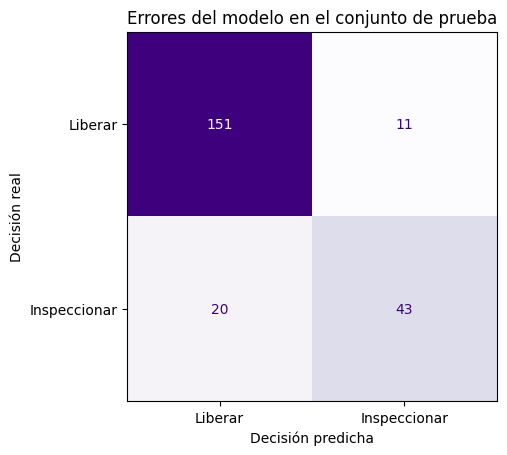

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_prueba,
    predicciones_modelo,
    labels=[0, 1],
    display_labels=["Liberar", "Inspeccionar"],
    cmap="Purples",
    colorbar=False,
)
plt.title("Errores del modelo en el conjunto de prueba")
plt.xlabel("Decisión predicha")
plt.ylabel("Decisión real")
plt.show()

### ¿Cómo se traducen las cuatro celdas?

`ravel()` extrae los valores en el orden VN, FP, FN y VP porque las etiquetas fueron fijadas como `[0, 1]`. El `DataFrame` agrega una explicación de negocio a cada cantidad.

En este contexto, el falso negativo merece atención especial: significa liberar una pieza que realmente requería inspección.

In [14]:
verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = matriz.ravel()

detalle_errores = pd.DataFrame({
    "componente": ["VN", "FP", "FN", "VP"],
    "cantidad": [verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos],
    "lectura": [
        "Pieza liberable identificada correctamente",
        "Pieza liberable enviada a inspección",
        "Pieza que requería inspección liberada por error",
        "Pieza que requería inspección identificada correctamente",
    ],
})
detalle_errores

,componente,cantidad,lectura
0,VN,151,Pieza liberable identificada correctamente
1,FP,11,Pieza liberable enviada a inspección
2,FN,20,Pieza que requería inspección liberada por error
3,VP,43,Pieza que requería inspección identificada cor...


## 6. Explorar el efecto del umbral

El modelo produce una probabilidad para la clase positiva. Aquí probaremos varios umbrales. Un umbral menor suele enviar más piezas a inspección; uno mayor puede reducir alertas, pero también dejar pasar más piezas que requerían revisión.

### ¿Qué cambia al modificar el umbral?

`predict_proba` devuelve la probabilidad estimada de que una pieza requiera inspección. En lugar de aceptar automáticamente el umbral predeterminado de 0.5, el ciclo prueba tres alternativas.

Para cada umbral se recalcula la matriz y la accuracy. La tabla permite observar el intercambio entre enviar piezas liberables a revisión y dejar pasar piezas que debían inspeccionarse.

In [15]:
probabilidades_inspeccion = modelo.predict_proba(X_prueba)[:, 1]
filas_umbrales = []

for umbral in [0.30, 0.50, 0.70]:
    predicciones_umbral = (probabilidades_inspeccion >= umbral).astype(int)
    vn, fp, fn, vp = confusion_matrix(y_prueba, predicciones_umbral, labels=[0, 1]).ravel()
    filas_umbrales.append({
        "umbral": umbral,
        "accuracy": accuracy_score(y_prueba, predicciones_umbral),
        "falsos_positivos": fp,
        "falsos_negativos": fn,
    })

tabla_umbrales = pd.DataFrame(filas_umbrales)
tabla_umbrales.round(3)

,umbral,accuracy,falsos_positivos,falsos_negativos
0,0.3,0.827,28,11
1,0.5,0.862,11,20
2,0.7,0.849,6,28


## Comprobaciones

La suma de VN, FP, FN y VP debe coincidir con el tamaño del conjunto de prueba. Además, la accuracy debe ser igual a `(VN + VP) / total`.

### ¿Qué verifican estas aserciones?

La primera comprobación confirma que las cuatro celdas de la matriz representan todas las observaciones de prueba. La segunda comprueba que la accuracy calculada desde VN y VP coincide con `accuracy_score`.

Si alguna aserción falla, hay una inconsistencia en las etiquetas, las predicciones o el cálculo de la métrica.

In [16]:
total_matriz = matriz.sum()
accuracy_desde_matriz = (verdaderos_negativos + verdaderos_positivos) / total_matriz

assert total_matriz == len(y_prueba)
assert np.isclose(accuracy_desde_matriz, accuracy_score(y_prueba, predicciones_modelo))

print("Comprobaciones superadas.")
print(f"Observaciones evaluadas: {total_matriz}")
print(f"Accuracy desde la matriz: {accuracy_desde_matriz:.3f}")

Comprobaciones superadas.
Observaciones evaluadas: 225
Accuracy desde la matriz: 0.862


## Conclusiones y siguientes pasos

La accuracy permite una lectura rápida del desempeño, mientras que la matriz de confusión muestra qué tipo de decisiones fueron correctas o incorrectas. En un proceso real, el umbral debería elegirse considerando el costo operativo de cada error.

Como siguiente ejercicio, modifica `weights`, `class_sep` o los umbrales y observa qué cambia. Para una evaluación más completa, incorpora precisión, recall, especificidad y una curva ROC o Precision-Recall.